# PySpark - DataFrames

## Create a DataFrame from a CSV file

Set up up the Spark master

- "local" for local execution
- "local[*]" for local execution using all core
- "spark://spark-master:7077" to connect to the Spark master running on the docker container


In [ ]:
master = "spark://spark-master:7077"
dataFolder = "/data/lab02/" if master == "spark://spark-master:7077" else "../data/"

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import column

spark = SparkSession.builder \
             .master(master) \
             .appName('flights') \
             .getOrCreate()

filename = dataFolder + 'flights.csv'
df = spark.read.option("delimiter", ",").option("header", True).option("inferSchema", "true").csv(filename)

df.printSchema()
df.show(5)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/24 08:51:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


root
 |-- day of Month: integer (nullable = true)
 |-- day of Week: integer (nullable = true)
 |-- carrier: string (nullable = true)
 |-- tailnum: string (nullable = true)
 |-- flnum: integer (nullable = true)
 |-- org_id: integer (nullable = true)
 |-- origin: string (nullable = true)
 |-- dest_id: integer (nullable = true)
 |-- dest: string (nullable = true)
 |-- scheduled dep time: integer (nullable = true)
 |-- dep time: integer (nullable = true)
 |-- departure delay: integer (nullable = true)
 |-- scheduled arr time: integer (nullable = true)
 |-- arr time: integer (nullable = true)
 |-- arrival delay: integer (nullable = true)
 |-- elapsed time: integer (nullable = true)
 |-- distance: integer (nullable = true)

+------------+-----------+-------+-------+-----+------+------+-------+----+------------------+--------+---------------+------------------+--------+-------------+------------+--------+
|day of Month|day of Week|carrier|tailnum|flnum|org_id|origin|dest_id|dest|scheduled dep

### Recast the type of a column

In [7]:
from pyspark.sql.types import  DoubleType

def convert_column(df, column, newType):
    return df.withColumn(column, df[column].cast(newType))


df2 = convert_column(df, "dep time", DoubleType())
df2.printSchema()
df2.select("dep time").show(5)

###  Defining a custom schema

In [3]:
from pyspark.sql.types import StringType, StructField, StructType, LongType, DoubleType, IntegerType

schema = (StructType([
					StructField("DayOfMonth", StringType(), False),
					StructField("DayOfWeek", StringType(), False),
					StructField("Carrier", StringType(), False),
					StructField("TailNum", StringType(), False),
					StructField("FlNum", IntegerType(), False),
					StructField("OrgId", LongType(), False),
					StructField("Origin", StringType(), False),
					StructField("DestId", LongType(), False),
					StructField("Dest", StringType(), False),
					StructField("ScheduledDepTime", DoubleType(), False),
					StructField("DepTime", DoubleType(), False),
					StructField("DepartureDelay", DoubleType(), False),
					StructField("ScheduledArrTime", DoubleType(), False),
					StructField("ArrTime", DoubleType(), False),
					StructField("ArrivalDelay", DoubleType(), False),
					StructField("ElapsedTime", DoubleType(), False),
					StructField("Distance", IntegerType(), False)]))

df = spark.read.schema(schema).option("delimiter", ",").option("header", True).csv(filename)

df.printSchema()
df.show(5)

root
 |-- DayOfMonth: string (nullable = true)
 |-- DayOfWeek: string (nullable = true)
 |-- Carrier: string (nullable = true)
 |-- TailNum: string (nullable = true)
 |-- FlNum: integer (nullable = true)
 |-- OrgId: long (nullable = true)
 |-- Origin: string (nullable = true)
 |-- DestId: long (nullable = true)
 |-- Dest: string (nullable = true)
 |-- ScheduledDepTime: double (nullable = true)
 |-- DepTime: double (nullable = true)
 |-- DepartureDelay: double (nullable = true)
 |-- ScheduledArrTime: double (nullable = true)
 |-- ArrTime: double (nullable = true)
 |-- ArrivalDelay: double (nullable = true)
 |-- ElapsedTime: double (nullable = true)
 |-- Distance: integer (nullable = true)

+----------+---------+-------+-------+-----+-----+------+------+----+----------------+-------+--------------+----------------+-------+------------+-----------+--------+
|DayOfMonth|DayOfWeek|Carrier|TailNum|FlNum|OrgId|Origin|DestId|Dest|ScheduledDepTime|DepTime|DepartureDelay|ScheduledArrTime|ArrTime

## Transformations: select, add, ...

In [9]:
df.select("Carrier").show()

In [10]:
df.select("Origin","Dest").show()


In [11]:
(df.selectExpr(
   "Origin","Dest",
    "(Distance > 1000) as LongDistance") # where condition
   .distinct().orderBy("Dest").show(100)
)

### Add

In [ ]:
from pyspark.sql.functions import expr

df2 = df.withColumn("FlightTime",  expr("ArrTime - DepTime")).select("Origin", "Dest", "FlightTime")
df2.show()

## Filter

In [15]:
df.where("DepTime > 2300").show()

## Aggregations

List of functions - https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql.html#functions

Flights per Route

In [16]:

df.groupBy("Origin", "Dest").count().show()


In [5]:
import pandas

pandas_df = df.toPandas()
pandas_df

/opt/spark/python/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,DayOfMonth,DayOfWeek,Carrier,TailNum,FlNum,OrgId,Origin,DestId,Dest,ScheduledDepTime,DepTime,DepartureDelay,ScheduledArrTime,ArrTime,ArrivalDelay,ElapsedTime,Distance
0,1,3,AA,N338AA,1,12478,JFK,12892,LAX,900.0,914.0,14.0,1225.0,1238.0,13.0,385.0,2475
1,2,4,AA,N338AA,1,12478,JFK,12892,LAX,900.0,857.0,0.0,1225.0,1226.0,1.0,385.0,2475
2,4,6,AA,N327AA,1,12478,JFK,12892,LAX,900.0,1005.0,65.0,1225.0,1324.0,59.0,385.0,2475
3,5,7,AA,N323AA,1,12478,JFK,12892,LAX,900.0,1050.0,110.0,1225.0,1415.0,110.0,385.0,2475
4,6,1,AA,N319AA,1,12478,JFK,12892,LAX,900.0,917.0,17.0,1225.0,1217.0,0.0,385.0,2475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441617,23,4,MQ,N518MQ,3419,10397,ATL,12953,LGA,1150.0,1148.0,0.0,1359.0,1350.0,0.0,129.0,762
441618,24,5,MQ,N9EAMQ,3419,10397,ATL,12953,LGA,1150.0,1150.0,0.0,1359.0,1404.0,5.0,129.0,762
441619,25,6,MQ,N0EGMQ,3419,10397,ATL,12953,LGA,1150.0,1229.0,39.0,1359.0,1448.0,49.0,129.0,762
441620,26,7,MQ,N8EGMQ,3419,10397,ATL,12953,LGA,1150.0,1147.0,0.0,1359.0,1342.0,0.0,129.0,762


In [6]:
pandas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 441622 entries, 0 to 441621
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DayOfMonth        441622 non-null  object 
 1   DayOfWeek         441622 non-null  object 
 2   Carrier           441622 non-null  object 
 3   TailNum           441622 non-null  object 
 4   FlNum             441622 non-null  int32  
 5   OrgId             441622 non-null  int64  
 6   Origin            441622 non-null  object 
 7   DestId            441622 non-null  int64  
 8   Dest              441622 non-null  object 
 9   ScheduledDepTime  441622 non-null  float64
 10  DepTime           441622 non-null  float64
 11  DepartureDelay    441622 non-null  float64
 12  ScheduledArrTime  441622 non-null  float64
 13  ArrTime           440453 non-null  float64
 14  ArrivalDelay      439620 non-null  float64
 15  ElapsedTime       441622 non-null  float64
 16  Distance          44

Select first 5 columns

In [7]:
pandas_df[0:5]

,DayOfMonth,DayOfWeek,Carrier,TailNum,FlNum,OrgId,Origin,DestId,Dest,ScheduledDepTime,DepTime,DepartureDelay,ScheduledArrTime,ArrTime,ArrivalDelay,ElapsedTime,Distance
0,1,3,AA,N338AA,1,12478,JFK,12892,LAX,900.0,914.0,14.0,1225.0,1238.0,13.0,385.0,2475
1,2,4,AA,N338AA,1,12478,JFK,12892,LAX,900.0,857.0,0.0,1225.0,1226.0,1.0,385.0,2475
2,4,6,AA,N327AA,1,12478,JFK,12892,LAX,900.0,1005.0,65.0,1225.0,1324.0,59.0,385.0,2475
3,5,7,AA,N323AA,1,12478,JFK,12892,LAX,900.0,1050.0,110.0,1225.0,1415.0,110.0,385.0,2475
4,6,1,AA,N319AA,1,12478,JFK,12892,LAX,900.0,917.0,17.0,1225.0,1217.0,0.0,385.0,2475


In [8]:
result = pandas_df.groupby("Origin").agg({'Distance' : 'min'})
result

,Distance
Origin,
ABE,425
ABI,158
ABQ,328
ABR,257
ABY,145
...,...
VPS,250
WRG,31
XNA,280


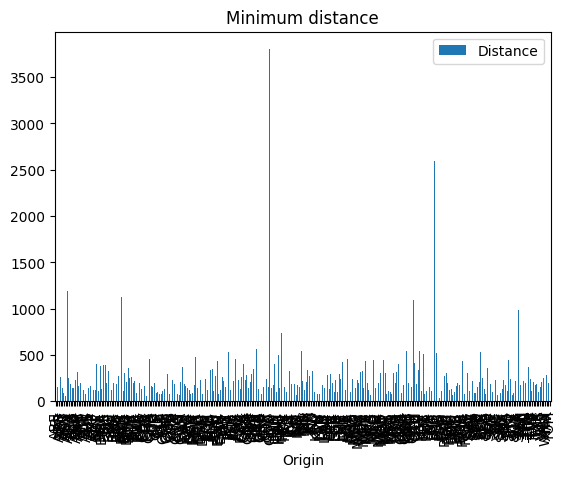

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
# plot the results
result.plot(kind='bar', title='Minimum distance');